# Credit Card Default Prediction (UCI Dataset)

Goal: build models to predict whether a credit-card customer will default next month and identify the main risk drivers.

Dataset: *UCI Credit Card Default* (30,000 clients, 25 features).
Target: `default.payment.next.month` (1 = default, 0 = no default).

# 1. Imports

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. Load data and quick EDA

In [77]:
# Load credit card default dataset (adjust path if needed)
df = pd.read_csv("../data/UCI_Credit_Card.csv")

# Quick look
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [78]:
# Structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [79]:
# Basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [80]:
# Target balance
df["default.payment.next.month"].value_counts(normalize=True)

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

# 3. Check missing values explicitly

In [81]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

# 4. Basic cleaning and feature engineering

In [82]:
# 4.1 Winsorization (clipping) of extreme values for bill and payment amounts
amount_cols = [c for c in df.columns if "BILL_AMT" in c or "PAY_AMT" in c]

for col in amount_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

# 4.2 Drop ID (not useful for prediction)
target = "default.payment.next.month"
df = df.drop(columns=["ID"])

# 4.3 Features and target
X = df.drop(columns=[target])
y = df[target]

# 4.4 Categorical columns to encode
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = [c for c in X.columns if c not in cat_cols]

# 4.5 One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_encoded.head()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,...,True,False,True,False,False,False,False,True,False,False
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,...,True,False,True,False,False,False,False,False,True,False
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,...,True,False,True,False,False,False,False,False,True,False
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,...,True,False,True,False,False,False,False,True,False,False
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,...,False,False,True,False,False,False,False,True,False,False


In [83]:
# 5. Train/Test split and scaling

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((24000, 30), (6000, 30))

# 6. Model 1 – Logistic Regression (baseline)

In [85]:
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="liblinear"  # n_jobs removed; not used by liblinear
)

log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Metrics
auc_lr = roc_auc_score(y_test, y_proba_lr)
print("AUC Logistic Regression:", auc_lr)

print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix (Logistic Regression):\n")
print(confusion_matrix(y_test, y_pred_lr))

AUC Logistic Regression: 0.7155270436348818

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.87      0.68      0.76      4673
           1       0.36      0.64      0.46      1327

    accuracy                           0.67      6000
   macro avg       0.62      0.66      0.61      6000
weighted avg       0.76      0.67      0.70      6000

Confusion Matrix (Logistic Regression):

[[3172 1501]
 [ 476  851]]


# 7. Curves for Logistic Regression

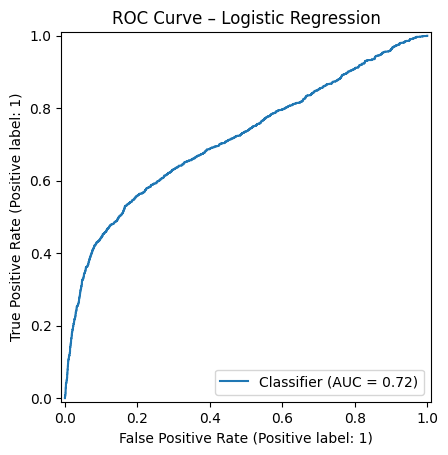

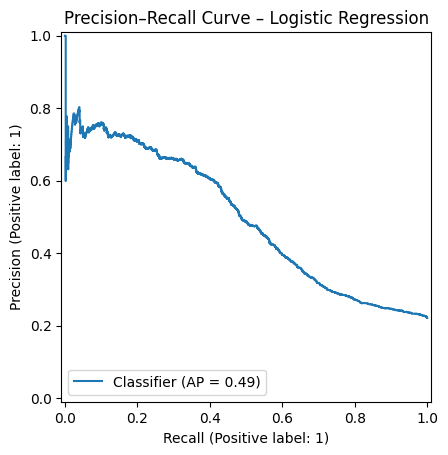

In [86]:
RocCurveDisplay.from_predictions(y_test, y_proba_lr)
plt.title("ROC Curve – Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr)
plt.title("Precision–Recall Curve – Logistic Regression")
plt.show()

# 8. Model 2 – Random Forest (main model)

In [87]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)
print("AUC Random Forest:", auc_rf)

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix (Random Forest):\n")
print(confusion_matrix(y_test, y_pred_rf))

AUC Random Forest: 0.7705077074589213

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4673
           1       0.54      0.53      0.53      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.79      0.79      0.79      6000

Confusion Matrix (Random Forest):

[[4063  610]
 [ 623  704]]


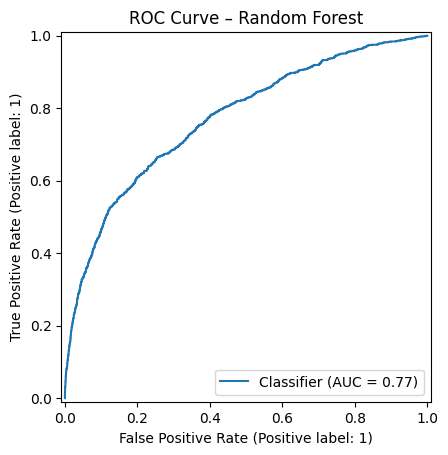

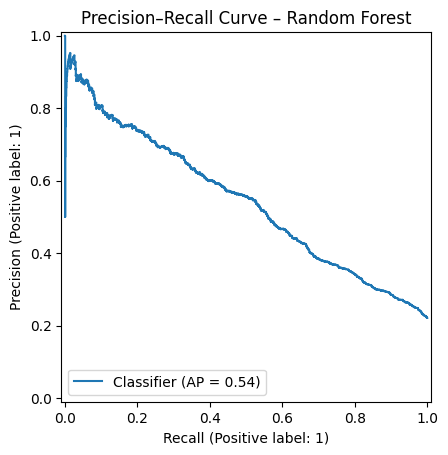

In [65]:
# ROC and Precision–Recall curves for Random Forest

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve – Random Forest")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Precision–Recall Curve – Random Forest")
plt.show()

# 9. Curves for Random Forest

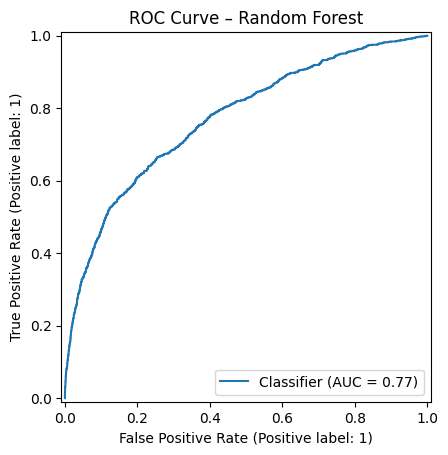

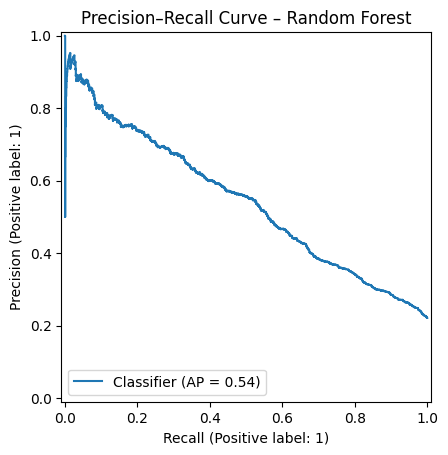

In [88]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve – Random Forest")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Precision–Recall Curve – Random Forest")
plt.show()

# 10. Cross-validation for Random Forest

In [89]:
rf_cv = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_cv,
    X_encoded,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest CV ROC AUC mean:", cv_scores.mean())
print("Random Forest CV ROC AUC std:", cv_scores.std())

Random Forest CV ROC AUC mean: 0.7755395739996032
Random Forest CV ROC AUC std: 0.02168696901084379


# 11. Hyperparameter tuning – GridSearchCV for Random Forest

In [91]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

grid = GridSearchCV(
    rf_base,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_rf = grid.best_estimator_

# VERY IMPORTANT: define these BEFORE using y_proba_best in plots
y_proba_best = best_rf.predict_proba(X_test)[:, 1]
y_pred_best = best_rf.predict(X_test)

auc_best = roc_auc_score(y_test, y_proba_best)
print("AUC Best Random Forest:", auc_best)

print("\nClassification Report (Best Random Forest):\n")
print(classification_report(y_test, y_pred_best))

print("Confusion Matrix (Best Random Forest):\n")
print(confusion_matrix(y_test, y_pred_best))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 500}
Best CV AUC: 0.7788335816743137
AUC Best Random Forest: 0.7742050526433255

Classification Report (Best Random Forest):

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000

Confusion Matrix (Best Random Forest):

[[3924  749]
 [ 560  767]]


# 12. Curves for Best Random Forest (GridSearch)

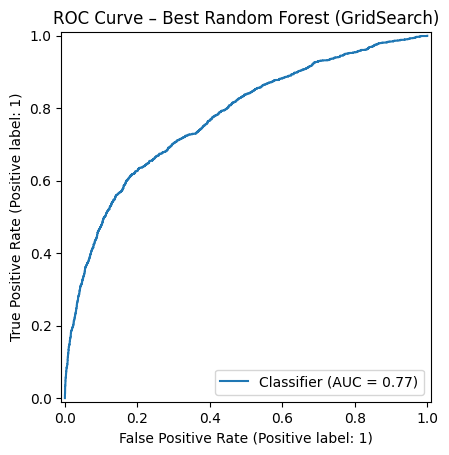

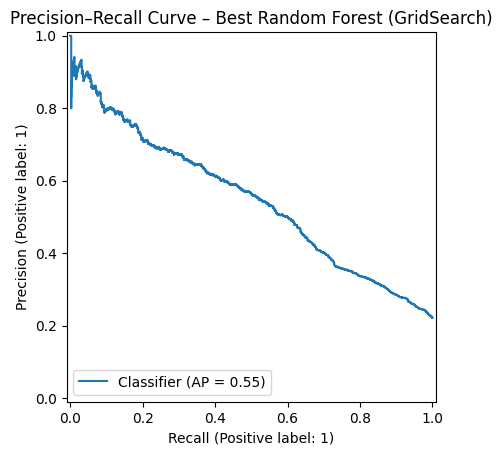

In [92]:
RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title("ROC Curve – Best Random Forest (GridSearch)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_best)
plt.title("Precision–Recall Curve – Best Random Forest (GridSearch)")
plt.show()

# 13. Threshold optimization (F1-score) for Best Random Forest

In [93]:
thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold (by F1):", best_t)
print("Best F1 score:", max(f1_scores))

# Predictions with optimized threshold
y_pred_best_opt = (y_proba_best >= best_t).astype(int)

print("\nClassification Report (Best RF with optimized threshold):\n")
print(classification_report(y_test, y_pred_best_opt))

print("Confusion Matrix (Best RF with optimized threshold):\n")
print(confusion_matrix(y_test, y_pred_best_opt))

Best threshold (by F1): 0.48
Best F1 score: 0.5451505016722408

Classification Report (Best RF with optimized threshold):

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.49      0.61      0.55      1327

    accuracy                           0.77      6000
   macro avg       0.69      0.72      0.70      6000
weighted avg       0.80      0.77      0.78      6000

Confusion Matrix (Best RF with optimized threshold):

[[3825  848]
 [ 512  815]]


# 14. Feature importance – Best Random Forest

In [94]:
importances = best_rf.feature_importances_
feat_names = X_train.columns

fi = pd.DataFrame({"feature": feat_names, "importance": importances})
fi_sorted = fi.sort_values("importance", ascending=False)

fi_sorted.head(10)

,feature,importance
2,PAY_0,0.272607
3,PAY_2,0.136001
4,PAY_3,0.087476
5,PAY_4,0.061742
6,PAY_5,0.048289
0,LIMIT_BAL,0.044815
14,PAY_AMT1,0.039765
15,PAY_AMT2,0.036533
7,PAY_6,0.036470
16,PAY_AMT3,0.033161


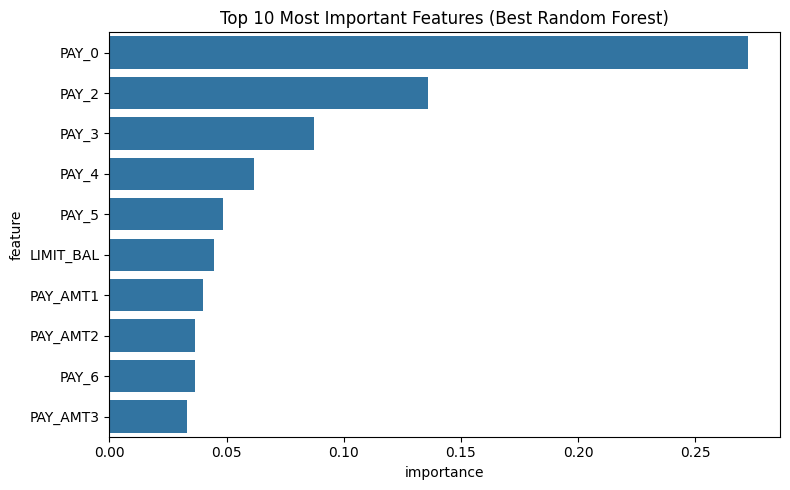

In [95]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=fi_sorted.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 Most Important Features (Best Random Forest)")
plt.tight_layout()
plt.show()

# 7. Business Insights
Based on the Random Forest model and feature importance analysis, several key insights emerge regarding credit card default behavior


1. Late payment behavior is the strongest predictor of default

Features such as PAY_0, PAY_2, PAY_3, and PAY_4 are the top predictors.

Interpretation:

Customers who have recent late payments (especially in the last 1–3 months) are significantly more likely to default next month.

The recency of delinquency matters more than the severity.

Business actions:

Prioritize customers with recent missed payments for early intervention.

Trigger SMS/email reminders or assign them to a “high-risk contact queue”.

Offer short-term payment plans to avoid delinquency escalation.


2. Credit utilization and outstanding balances also increase default risk

Features like LIMIT_BAL, BILL_AMT1, BILL_AMT2, PAY_AMT1, etc., appear consistently in the top importance rankings.

Interpretation:

Higher balances relative to credit limit lead to higher financial stress.

Customers paying only minimum amounts may be showing early signs of inability to repay.

Business actions:

Flag high-utilization customers for proactive credit-limit review.

Offer financial planning tools or spend alerts.

Provide “minimum payment warning” notifications.


3. Payment amounts in recent months have predictive power

Lower repayment amounts (PAY_AMT1, PAY_AMT2) indicate weakening repayment capacity.

Business actions:

Build a repayment-behavior score to track declining payment trends.

Offer personalized installment options for those whose payments shrink month over month.


4. Model performance

The optimized Random Forest achieves an AUC ≈ 0.77, which is strong for a risk-scoring model.

Optimizing the decision threshold increases the recall for defaulters, which is crucial in risk management.

Business implication:

The model is reliable for operational decision-making.

It can be used to reduce overall portfolio risk through targeted interventions.


Real-World Applications
A. Risk Management & Collections

Early detection of high-risk customers allows the bank to reduce future default losses.

Create risk tiers (Low–Medium–High) based on predicted probability of default.

Assign different collection strategies per risk segment.


B. Credit Line Management

Adjust credit limits dynamically based on predicted default probability.

Pause automatic credit line increases for high-risk customers.

Offer reduced APR (interest rate) for stable, low-risk customers to increase loyalty.


C. Customer Retention & Support

Identify customers under financial stress before they fully default.

Offer temporary payment relief programs (e.g., skip-a-payment, hardship plans).


D. Monitoring & Reporting

Track the model’s performance monthly (AUC, recall, false positives).

Integrate predictions into dashboards for Operations, Risk, and Finance teams.

Evaluate portfolio exposure by customer segment, region, and demographic groups.